In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

def plot_likelihood_scan(root_file, poi_name, output_name="likelihood_scan.png"):
    """
    Reads a Combine MultiDimFit root file and plots the 1D likelihood scan.
    """
    print(f"Opening {root_file}...")
    
    # 1. Open the file and extract the tree
    with uproot.open(root_file) as f:
        tree = f["limit"]
        
        # Extract the Parameter of Interest and the deltaNLL branches
        poi_vals = tree[poi_name].array(library="np")
        dnll_vals = tree["deltaNLL"].array(library="np")

    # 2. Separate the best-fit point (index 0) from the grid points (index 1+)
    best_fit_poi = poi_vals[0]
    
    grid_poi = poi_vals[1:]
    grid_dnll = dnll_vals[1:]
    
    # Multiply by 2 to get 2*deltaNLL (which follows a chi-squared distribution)
    y_vals = 2 * grid_dnll
    
    # Sort the grid points so matplotlib draws a continuous, smooth curve
    sort_idx = np.argsort(grid_poi)
    x_sorted = grid_poi[sort_idx]
    y_sorted = y_vals[sort_idx]

    # 3. Plotting
    plt.figure(figsize=(8, 6))
    
    # Plot the main likelihood curve
    plt.plot(x_sorted, y_sorted, 'b-', linewidth=2, label='Expected Scan')
    
    # Mark the best fit point
    plt.plot(best_fit_poi, 0, 'r*', markersize=12, label=f'Best Fit: {best_fit_poi:.2f}')

    # Add the 1-sigma (68% CL) and 2-sigma (95% CL) intersection lines
    plt.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='1$\sigma$ (68% CL)')
    plt.axhline(3.84, color='black', linestyle='-.', alpha=0.7, label='2$\sigma$ (95% CL)')

    # Formatting
    plt.xlabel(f'{poi_name} (Wilson Coefficient)', fontsize=14)
    plt.ylabel('$-2 \Delta \ln \mathcal{L}$', fontsize=14)
    plt.title(f'1D Expected Likelihood Scan for {poi_name} (others profiled)', fontsize=16)
    
    # Set y-axis limits (cutting it off slightly above the 2-sigma line looks cleanest)
    plt.ylim(0, 6.0) 
    
    # Add a minor grid for readability
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    #plt.legend(loc='upper center', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(output_name, dpi=300)
    print(f"Saved plot to {output_name}")
    plt.show()

Opening /cms/data/jsamudio/boosted/CMSSW_14_1_0_pre4/src/HiggsAnalysis/CombinedLimit/higgsCombine_cthre_profiledblinded.MultiDimFit.mH125.root...
Saved plot to scan_cthre.png


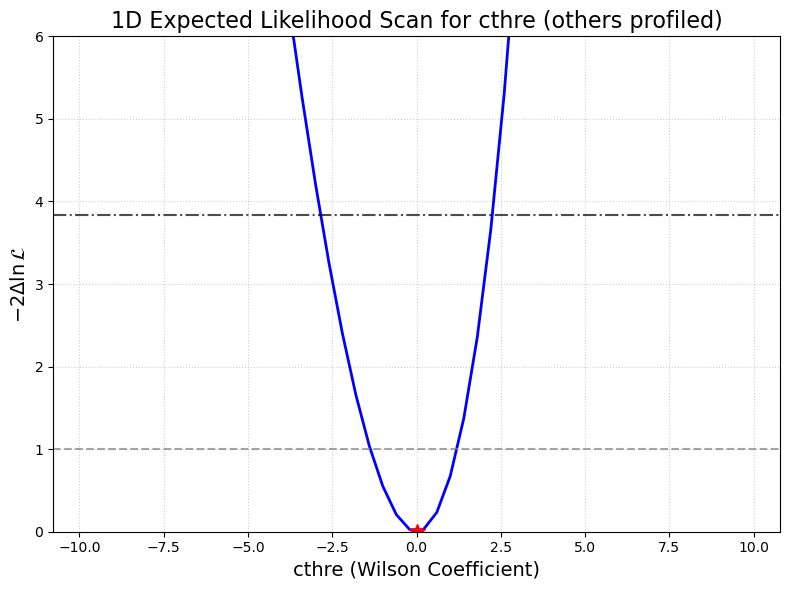

In [4]:
file_name = "/cms/data/jsamudio/boosted/CMSSW_14_1_0_pre4/src/HiggsAnalysis/CombinedLimit/higgsCombine_cthre_profiledblinded.MultiDimFit.mH125.root"
    
plot_likelihood_scan(file_name, poi_name="cthre", output_name="scan_cthre.png")